In [99]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [100]:
df=pd.read_csv("MODEL TWO.csv")
df.tail()

,pH,TDS_ppm,Turbidity_NTU,Temperature_C,Label
100795,7.85,1150.7,28.62,25.84,Unsafe
100796,8.28,993.4,25.85,26.00,Unsafe
100797,8.09,1105.9,25.40,26.86,Unsafe
100798,8.16,1060.5,28.47,26.62,Unsafe
100799,8.23,1087.0,34.08,26.11,Unsafe


In [101]:
df.shape

(100800, 5)

In [102]:
df.columns

Index(['pH', 'TDS_ppm', 'Turbidity_NTU', 'Temperature_C', 'Label'], dtype='object')

In [103]:
df.columns = df.columns.str.lower()
df.columns

Index(['ph', 'tds_ppm', 'turbidity_ntu', 'temperature_c', 'label'], dtype='object')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100800 entries, 0 to 100799
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ph             100800 non-null  float64
 1   tds_ppm        100800 non-null  float64
 2   turbidity_ntu  100800 non-null  float64
 3   temperature_c  100800 non-null  float64
 4   label          100800 non-null  object 
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [105]:
df.isnull().sum()

ph               0
tds_ppm          0
turbidity_ntu    0
temperature_c    0
label            0
dtype: int64

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df['label'].value_counts()

label
Unsafe    70560
Safe      30240
Name: count, dtype: int64

In [108]:
df["label"]=df["label"].map({"Unsafe":1,"Safe":0})

In [109]:
df.head()

,ph,tds_ppm,turbidity_ntu,temperature_c,label
0,7.38,138.7,0.25,20.25,0
1,7.42,79.2,0.45,20.14,0
2,7.05,104.1,1.18,20.12,0
3,7.32,112.8,0.53,19.65,0
4,6.87,171.9,1.97,19.42,0


In [110]:
df.describe()

,ph,tds_ppm,turbidity_ntu,temperature_c,label
count,100800.000000,100800.000000,100800.000000,100800.000000,100800.00000
mean,7.593915,692.646992,11.306750,24.883516,0.70000
std,0.799464,647.331906,9.868407,2.688138,0.45826
min,6.090000,28.600000,0.000000,16.560000,0.00000
25%,7.010000,163.000000,1.920000,23.090000,0.00000
50%,7.380000,472.850000,9.970000,25.040000,1.00000
75%,8.100000,1023.325000,18.540000,26.930000,1.00000
max,9.960000,2806.100000,72.750000,31.510000,1.00000


In [111]:
x=df.drop(columns=["label"])
y=df["label"]

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Building The Model

XGBoost Model Performance:
Accuracy: 0.9998511904761904
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6050
           1       1.00      1.00      1.00     14110

    accuracy                           1.00     20160
   macro avg       1.00      1.00      1.00     20160
weighted avg       1.00      1.00      1.00     20160



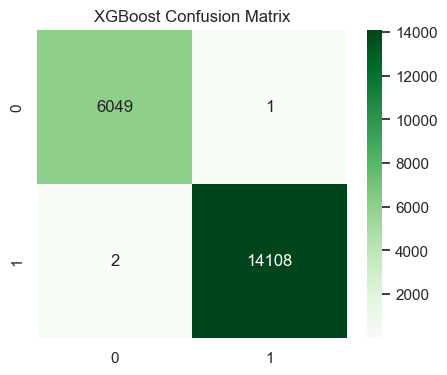

In [113]:
# Initialize the XGBoost classifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the XGBoost model
xgb_model.fit(x_train_scaled, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(x_test_scaled)

# Evaluate XGBoost model performance
print("XGBoost Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.show()

In [114]:
train_pred = xgb_model.predict(x_train_scaled)
test_pred = xgb_model.predict(x_test_scaled)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9999875992063492
Test Accuracy: 0.9998511904761904


In [121]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

         Feature  Importance
1        tds_ppm    0.992143
2  turbidity_ntu    0.007413
3  temperature_c    0.000264
0             ph    0.000180


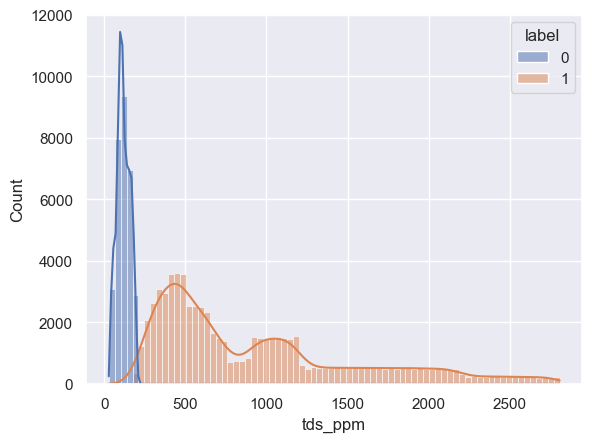

In [122]:
sns.histplot(data=df, x="tds_ppm", hue="label", kde=True)
plt.show()

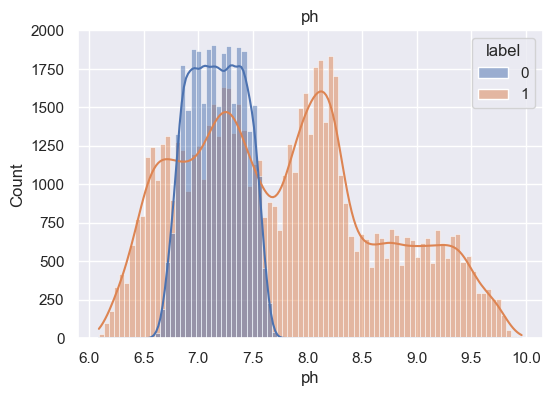

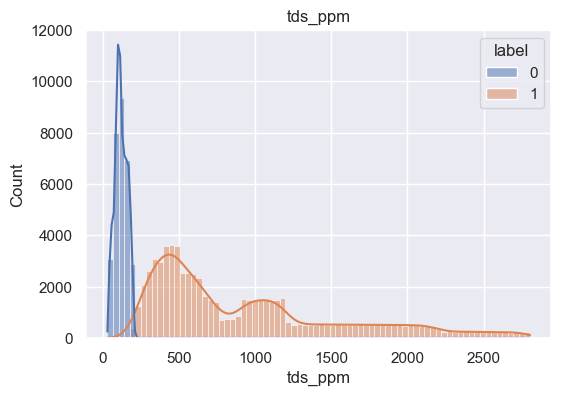

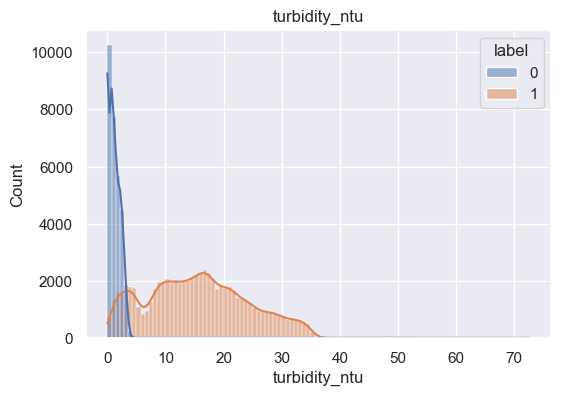

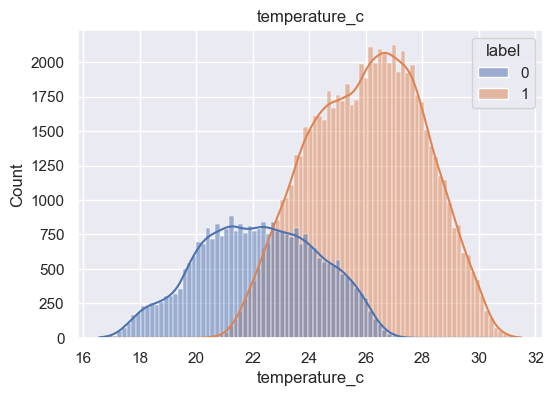

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["ph", "tds_ppm", "turbidity_ntu", "temperature_c"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=feature, hue="label", kde=True)
    plt.title(feature)
    plt.show()

In [125]:
import joblib

joblib.dump(xgb_model, "water_contamination_model.pkl")

['water_contamination_model.pkl']